In [3]:
!pip install easyocr

  Using cached easyocr-1.7.2-py3-none-any.whl.metadata (10 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 23.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.7/180.7 kB 11.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 978.2/978.2 kB 32.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 299.6/299.6 kB 16.2 MB/s eta 0:00:00


In [4]:
import cv2
import numpy as np
import easyocr


def detect_text_boxes(image_path: str, langs: List[str] = ['ru', 'en']) -> List[Tuple[int, int, int, int]]:
    """
    Находит текст на изображении и возвращает список координат прямоугольников.
    Что возвращает: [(x1, y1, x2, y2), ...]
    """
    img = cv2.imread(image_path)
    if img is None:
        raise FileNotFoundError(f"Не удалось загрузить: {image_path}")

    reader = easyocr.Reader(langs, gpu=False, verbose=False)
    results = reader.readtext(img)

    # координаты прямоугольников, которые являются результатом этой функции
    boxes = []
    for bbox, text, score in results
        xs = [int(p[0]) for p in bbox]
        ys = [int(p[1]) for p in bbox]
        x1, y1 = min(xs), min(ys)
        x2, y2 = max(xs), max(ys)
        boxes.append((x1, y1, x2, y2))

    return boxes


def extract_text_only(image_path: str, boxes: List[Tuple[int, int, int, int]], padding: int = 2) -> np.ndarray:
    """
    Функция, которая убирает всю информацию из изображения, оставляя только текст,
    и изменяет цвет на оттенки серого для уменьшении веса итогого изображения
    """
    img = cv2.imread(image_path)
    if img is None:
        raise FileNotFoundError(f"Не удалось загрузить: {image_path}")

    h, w = img.shape[:2]
    mask = np.zeros((h, w), dtype=np.uint8)

    # маска
    for x1, y1, x2, y2 in boxes:
        x1_p = max(0, x1 - padding)
        y1_p = max(0, y1 - padding)
        x2_p = min(w, x2 + padding)
        y2_p = min(h, y2 + padding)
        cv2.rectangle(mask, (x1_p, y1_p), (x2_p, y2_p), 255, -1)

    # Обнуление ненужной информации
    result = np.zeros_like(img)
    result[mask == 255] = img[mask == 255]

    # Уничтожение цвета
    final_var = cv2.cvtColor(result, cv2.COLOR_BGR2GRAY)

    return final_var

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


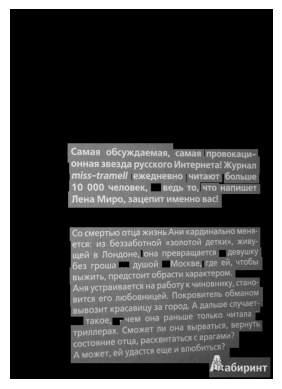

In [9]:

image = "/test.jpg" # изображение
boxes = detect_text_boxes(image) # координаты прямоугольников
final_var = extract_text_only(image, boxes, padding=2) # итоговое изображение

#вывод
import matplotlib.pyplot as plt
plt.imshow(final_var, cmap='gray')
plt.axis('off')
plt.show()